In [ ]:
from google.colab import drive
import os
import matplotlib.pyplot as plt
import numpy as np
import random
import tensorflow as tf
import cv2
import seaborn as sns
import matplotlib.cm as cm

# 1. Collegamento del Drive e caricamento del dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
numero_seed = 42

os.environ['PYTHONHASHSEED'] = str(numero_seed)
random.seed(numero_seed)
np.random.seed(numero_seed)
tf.random.set_seed(numero_seed)

In [ ]:
import zipfile

dataset_zip = "/content/drive/MyDrive/archive.zip"
dataset_dir = "/tmp/dataset"

with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

dataset_path = os.path.join(dataset_dir, "dataset")
print("Dataset scaricato.")

Dataset scaricato.


# 2. Analisi del dataset

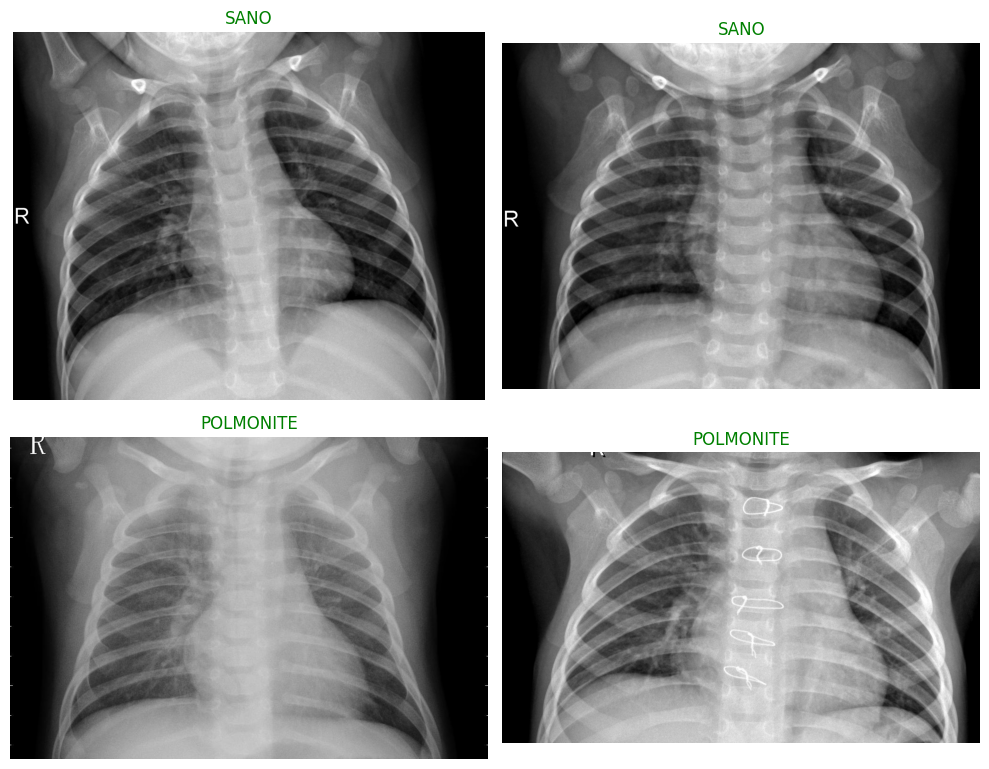

In [ ]:
base_dir = '/tmp/dataset/chest_xray'
train_normal_dir = os.path.join(base_dir, 'train', 'NORMAL')
train_pneumonia_dir = os.path.join(base_dir, 'train', 'PNEUMONIA')

normal_list = os.listdir(train_normal_dir)
pneumonia_list = os.listdir(train_pneumonia_dir)

normal_sample = random.sample(normal_list, 2)
pneumonia_sample = random.sample(pneumonia_list, 2)
fig, assi = plt.subplots(2, 2, figsize = (10, 8))

for i, img in enumerate(normal_sample):
    img_path = cv2.imread(os.path.join(train_normal_dir, img))
    assi[0, i].imshow(img_path)
    assi[0, i].set_title("SANO", color = 'green')
    assi[0, i].axis('off')

for i, img in enumerate(pneumonia_sample):
    img_path = cv2.imread(os.path.join(train_pneumonia_dir, img))
    assi[1, i].imshow(img_path)
    assi[1, i].set_title("POLMONITE", color = 'green')
    assi[1, i].axis('off')

plt.tight_layout()
plt.show()

Numero di radiografie di pazienti sani: 1341 (dunque il: 25.7% delle immagini totali)
Numero di radiografie di pazienti malati: 3875 (dunque il: 74.3% delle immagini totali)


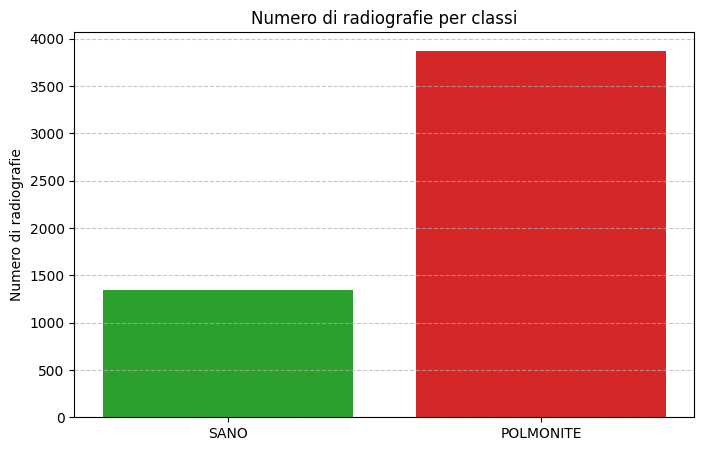

In [ ]:
number_of_normal = len(normal_list)
number_of_pneumonia = len(pneumonia_list)
total = number_of_normal + number_of_pneumonia

perc_normal = (number_of_normal / total) * 100
perc_pneumonia = (number_of_pneumonia / total) * 100
print(f"Numero di radiografie di pazienti sani: {number_of_normal} (dunque il: {perc_normal:.1f}% delle immagini totali)")
print(f"Numero di radiografie di pazienti malati: {number_of_pneumonia} (dunque il: {perc_pneumonia:.1f}% delle immagini totali)")

label = ['SANO', 'POLMONITE']
values = [number_of_normal, number_of_pneumonia]
colors = ['#2ca02c', '#d62728']

plt.figure(figsize = (8, 5))
plt.bar(label, values, color = colors)
plt.title('Numero di radiografie per classi')
plt.ylabel('Numero di radiografie')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

In [ ]:
first_normal_path = os.path.join(train_normal_dir, normal_list[0])
img_temp_1 = cv2.imread(first_normal_path)
height_1, lenght_1, color_1 = img_temp_1.shape
print(f"Dimensione dell'immagine della prima radiografia di un paziente sano: {height_1}x{lenght_1} pixel")

first_pneumonia_path = os.path.join(train_pneumonia_dir, pneumonia_list[0])
img_temp_2 = cv2.imread(first_pneumonia_path)
height_2, lenght_2, color_2 = img_temp_2.shape
print(f"Dimensione dell'immagine della prima radiografia di un paziente malato: {height_2}x{lenght_2} pixel")

Dimensione dell'immagine della prima radiografia di un paziente sano: 1604x1986 pixel
Dimensione dell'immagine della prima radiografia di un paziente malato: 568x952 pixel


# 3. Pre-processing dei dati

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

img_size = (224, 224)
batch_size = 32

# prepariamo le immagini andando a tagliare i bordi e ridefinendo la size
def preprocessing_pipeline(img):
  img_crop = tf.image.central_crop(img, central_fraction = 0.78)
  img_resize = tf.image.resize(img_crop, img_size)
  return preprocess_input(img_resize.numpy())

# data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocessing_pipeline,
    rotation_range = 10,
    zoom_range = 0.15,
    width_shift_range = 0.15,
    height_shift_range = 0.15,
    fill_mode = 'constant',
    cval = 0,
    validation_split = 0.20
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocessing_pipeline
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    subset = 'training',
    seed = numero_seed
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    subset = 'validation',
    seed = numero_seed
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    shuffle = False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


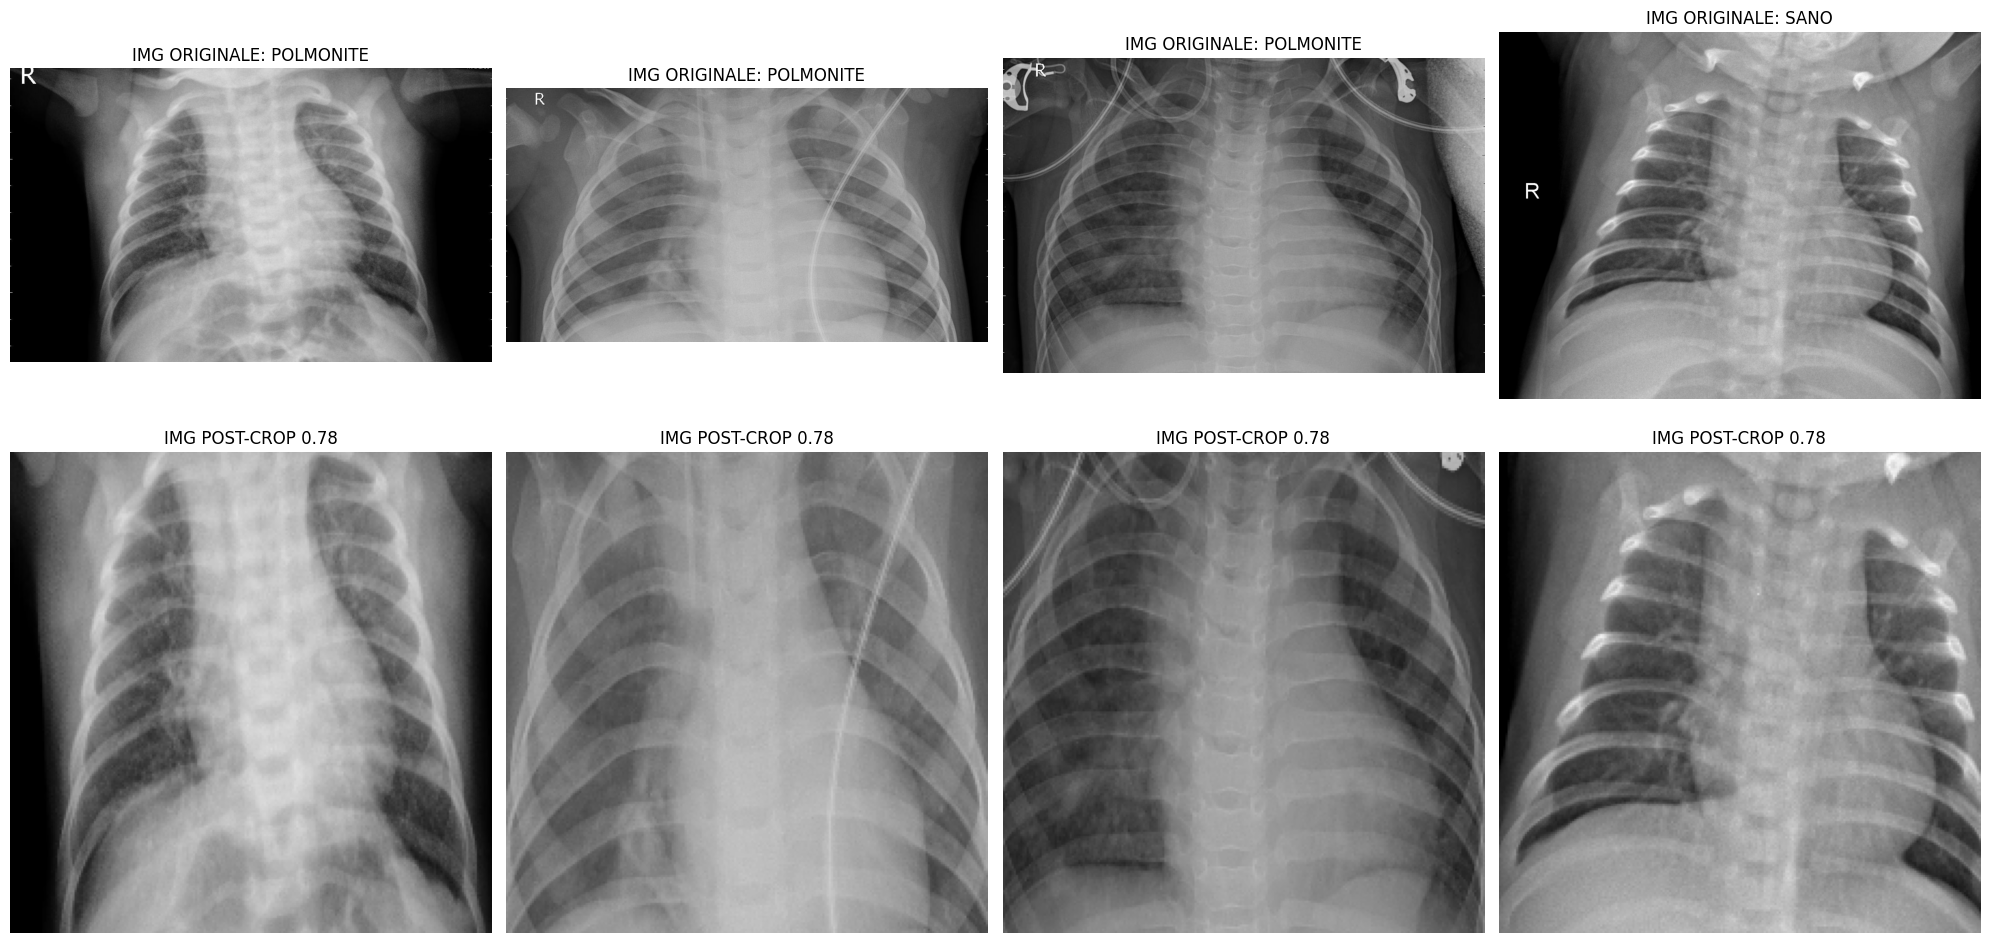

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

num_samples = 4
size = (224, 224)

def preprocessing_pipeline_visualizer(img):
  img_crop = tf.image.central_crop(img, central_fraction = 0.78)
  img_resize = tf.image.resize(img_crop, size)
  return img_resize.numpy().astype('uint8')

all_img = []
for img in os.listdir(train_normal_dir):
    all_img.append((os.path.join(train_normal_dir, img), 'SANO'))
for img in os.listdir(train_pneumonia_dir):
    all_img.append((os.path.join(train_pneumonia_dir, img), 'POLMONITE'))

visual_samples = random.sample(all_img, num_samples)
fig, assi = plt.subplots(2, 4, figsize=(20, 10))

for i, (img_path, ground_truth) in enumerate(visual_samples):
    original_img = load_img(img_path)
    original_array = img_to_array(original_img)

    cropped_img = preprocessing_pipeline_visualizer(original_array)

    assi[0, i].imshow(original_array.astype('uint8'))
    assi[0, i].set_title(f"IMG ORIGINALE: {ground_truth}")
    assi[0, i].axis('off')

    assi[1, i].imshow(cropped_img)
    assi[1, i].set_title(f"IMG POST-CROP 0.78")
    assi[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# i pesi sono stati calcolati secondo la logica balanced
weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_generator.classes),
    y = train_generator.classes
)

# trasformo i pesi in un dictionary
class_weights = dict(enumerate(weights.tolist()))
normal_weights = class_weights[0]
pneumonia_weights = class_weights[1]

print(f"I pesi bilanciati per gli errori sui sani sono: {normal_weights:.2f}, mentre per gli errori sui malati sono: {pneumonia_weights:.2f}.")

I pesi bilanciati per gli errori sui sani sono: 1.94, mentre per gli errori sui malati sono: 0.67.


# 4. Training

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model, load_model

base_model = ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)
base_model.trainable = False

# aggiunta dei nuovi layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation = 'relu')(x)
x = Dropout(0.5)(x)
final_output = Dense(1, activation = 'sigmoid')(x)

# istanziazione del modello finale
model_resnet = Model(
    inputs = base_model.input,
    outputs = final_output
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,637,313 (93.98 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall

save_drive = "/content/drive/MyDrive/progettoML_consegna.keras"

if os.path.exists(save_drive):
  print(f"Il modello è già presente in: {save_drive}.")
  model_resnet = load_model(save_drive)
else:
  save = ModelCheckpoint(
     filepath = save_drive,
     monitor = 'val_loss',
     verbose = 1,
     save_best_only = True
  )

  early_stop = EarlyStopping(
      monitor = 'val_loss',
      patience = 6,
      restore_best_weights = True
  )

  reduce_lr = ReduceLROnPlateau(
      monitor = 'val_loss',
      factor = 0.2,
      patience = 2,
      min_lr = 1e-7,
      verbose = 1
  )

  model_resnet.compile(
      optimizer = 'adam',
      loss = 'binary_crossentropy',
      metrics = ['accuracy', Precision(name = 'precision'), Recall(name = 'recall')]
  )

  history_resnet = model_resnet.fit(
      train_generator,
      epochs = 30,
      validation_data = val_generator,
      class_weight = class_weights,
      callbacks = [save, early_stop, reduce_lr]
  )

  print("Training terminato con successo.")

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.8306 - loss: 0.4700 - precision: 0.9313 - recall: 0.8322
Epoch 1: val_loss improved from None to 0.23653, saving model to /content/drive/MyDrive/progettoML_consegna.keras

Epoch 1: finished saving model to /content/drive/MyDrive/progettoML_consegna.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.8799 - loss: 0.3224 - precision: 0.9558 - recall: 0.8790 - val_accuracy: 0.9060 - val_loss: 0.2365 - val_precision: 0.9899 - val_recall: 0.8826 - learning_rate: 0.0010
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 944ms/step - accuracy: 0.9269 - loss: 0.1867 - precision: 0.9765 - recall: 0.9244
Epoch 2: val_loss improved from 0.23653 to 0.13933, saving model to /content/drive/MyDrive/progettoML_consegna.keras

Epoch 2: finished saving model to /content/drive/MyDrive/progettoML_consegna.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9255 - loss: 0.1881 - precision: 0.9761 - recall: 0.9223 - val_accuracy

# 5. Fine Tuning

In [ ]:
from tensorflow.keras.optimizers import Adam

# scongelo tutti i layer
for layer in model_resnet.layers:
    layer.trainable = True

# mantengo congelati i primi 95 layer
freeze_threshold = 95
for layer in model_resnet.layers[:freeze_threshold]:
  layer.trainable = False

# compilo il modello per la fase di Fine-Tuning
model_resnet.compile(
    optimizer = Adam(learning_rate = 1e-5),
    loss = 'binary_crossentropy',
    metrics = ['accuracy', Precision(name = 'precision'), Recall(name = 'recall')]
)

model_resnet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,637,313 (93.98 MB)

 Trainable params: 21,356,289 (81.47 MB)

 Non-trainable params: 3,281,024 (12.52 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall

save_drive_finetuning = "/content/drive/MyDrive/progettoML_FineTuning_consegna.keras"

if os.path.exists(save_drive_finetuning):
  print(f"Il modello dopo il fine tuning è già presente in: {save_drive_finetuning}.")
  model_resnet = load_model(save_drive_finetuning)
else:
  save_finetuning = ModelCheckpoint(
      filepath = save_drive_finetuning,
      monitor = 'val_loss',
      verbose = 1,
      save_best_only = True
  )

  early_stop = EarlyStopping(
      monitor = 'val_loss',
      patience = 6,
      restore_best_weights = True
  )

  reduce_lr = ReduceLROnPlateau(
      monitor = 'val_loss',
      factor = 0.2,
      patience = 2,
      min_lr = 1e-7,
      verbose = 1
  )

  model_resnet.compile(
      optimizer = Adam(learning_rate = 1e-5),
      loss = 'binary_crossentropy',
      metrics = ['accuracy', Precision(name = 'precision'), Recall(name = 'recall')]
  )

  history_finetuning_resnet = model_resnet.fit(
     train_generator,
     epochs = 30,
     validation_data = val_generator,
     class_weight = class_weights,
     callbacks = [save_finetuning, early_stop, reduce_lr]
  )

  print("Fine Tuning terminato con successo.")

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9284 - loss: 0.2995 - precision: 0.9370 - recall: 0.9721
Epoch 1: val_loss improved from None to 0.27098, saving model to /content/drive/MyDrive/progettoML_FineTuning_consegna.keras

Epoch 1: finished saving model to /content/drive/MyDrive/progettoML_FineTuning_consegna.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.9403 - loss: 0.1994 - precision: 0.9657 - recall: 0.9535 - val_accuracy: 0.9089 - val_loss: 0.2710 - val_precision: 0.9985 - val_recall: 0.8787 - learning_rate: 1.0000e-05
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9441 - loss: 0.1266 - precision: 0.9879 - recall: 0.9371
Epoch 2: val_loss improved from 0.27098 to 0.14129, saving model to /content/drive/MyDrive/progettoML_FineTuning_consegna.keras

Epoch 2: finished saving model to /content/drive/MyDrive/progettoML_FineTuning_consegna.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9458 - loss: 0.1303 - precisi

# 6. Valutazione delle prestazioni

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 779ms/step


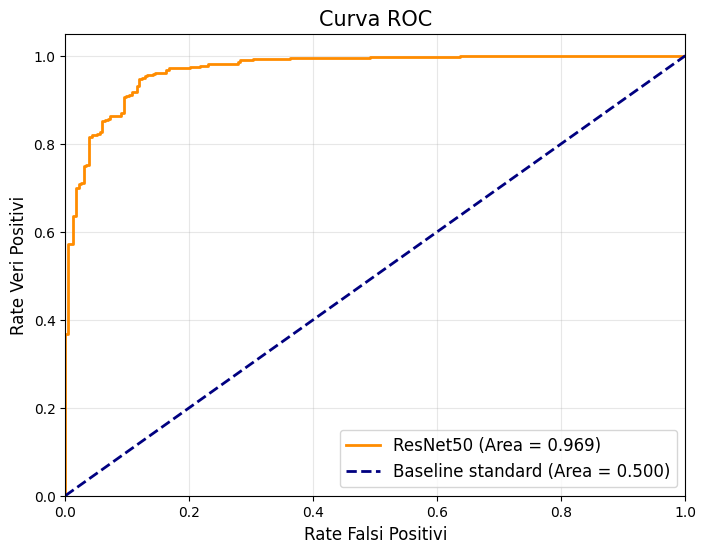


 PUNTEGGIO AUC FINALE: 0.969


In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# fase di inferenza
y_score = model_resnet.predict(test_generator)
y_true = test_generator.classes

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(false_positive_rate, true_positive_rate)

plt.figure(figsize = (8, 6))
# tracciamento della curva del mio modello
plt.plot(
    false_positive_rate,
    true_positive_rate,
    color = 'darkorange',
    lw = 2,
    label = f'ResNet50 (Area = {roc_auc:.3f})'
)
# tracciamento della baseline
plt.plot(
    [0, 1],
    [0, 1],
    color = 'navy',
    lw = 2,
    linestyle = '--',
    label = 'Baseline standard (Area = 0.500)'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel(
    'Rate Falsi Positivi',
    fontsize=12
)
plt.ylabel(
    'Rate Veri Positivi',
    fontsize=12
)
plt.title(
    'Curva ROC',
    fontsize=15
)
plt.legend(
    loc="lower right",
    fontsize=12
)
plt.grid(alpha=0.3)
plt.show()

print("\n" + "="*50)
print(f" PUNTEGGIO AUC FINALE: {roc_auc:.3f}")
print("="*50)

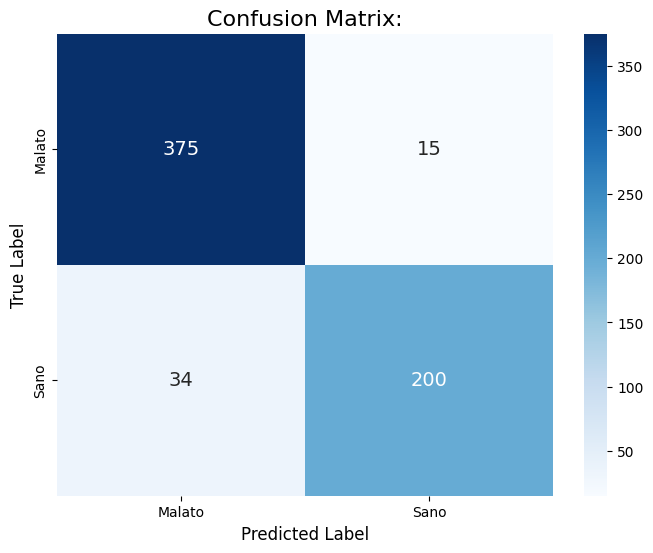


--- REPORT DI CLASSIFICAZIONE FINALE ---
              precision    recall  f1-score   support

        Sano       0.93      0.85      0.89       234
      Malato       0.92      0.96      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.91       624
weighted avg       0.92      0.92      0.92       624



In [ ]:
y_pred = (y_score > 0.7).astype(int).flatten()
conf_matrix = confusion_matrix(y_true, y_pred, labels = [1, 0])

plt.figure(figsize = (8, 6))
sns.heatmap(
    conf_matrix,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
     xticklabels=['Malato', 'Sano'],
            yticklabels=['Malato', 'Sano'],
            annot_kws={"size": 14}
)

plt.title('Confusion Matrix:', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

print("\n--- REPORT DI CLASSIFICAZIONE FINALE ---")
print(classification_report(y_true, y_pred, target_names=['Sano', 'Malato']))

# 7. Explainable AI: Grad-Cam

In [ ]:
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.4 MB/s eta 0:00:00


/tmp/ipykernel_1675/1013908625.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet_colors = cm.get_cmap("jet")(np.arange(256))[:, :3]


File: person138_bacteria_658.jpeg | Reale: POLMONITE | Previsione Modello: POLMONITE (99.19%)


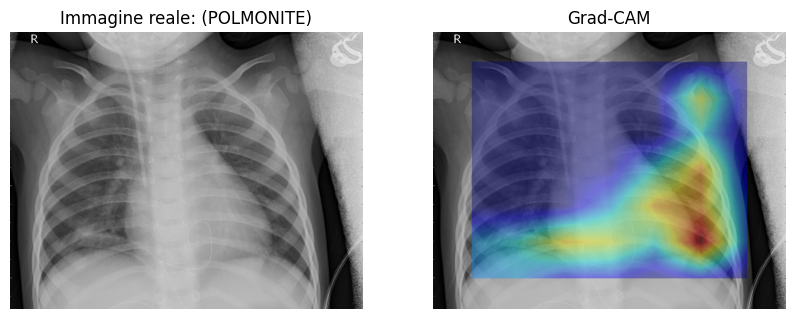

File: NORMAL2-IM-0303-0001.jpeg | Reale: SANO | Previsione Modello: SANO (93.23%)


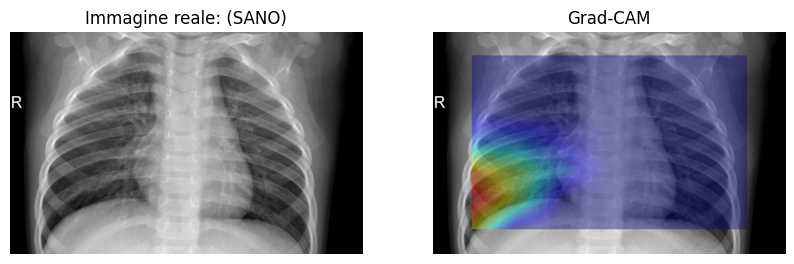

File: person121_bacteria_576.jpeg | Reale: POLMONITE | Previsione Modello: POLMONITE (100.00%)


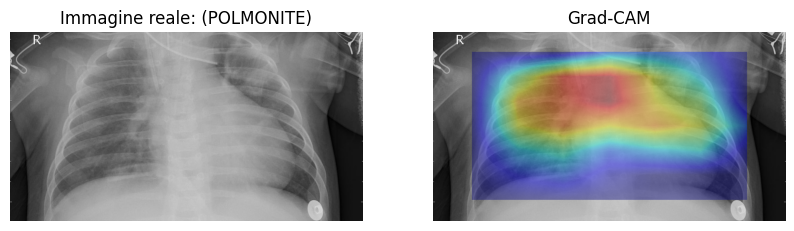

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tf_keras_vis.gradcam import Gradcam

num_samples = 3
last_conv_layer = "conv5_block3_out"
threshold = 0.7

all_img = []
test_normal_dir = os.path.join(test_dir, 'NORMAL')
test_pneumonia_dir = os.path.join(test_dir, 'PNEUMONIA')

for img in os.listdir(test_normal_dir):
    all_img.append((os.path.join(test_normal_dir, img), "SANO", img))
for img in os.listdir(test_pneumonia_dir):
    all_img.append((os.path.join(test_pneumonia_dir, img), "POLMONITE", img))

random_images = random.sample(all_img, num_samples)
gradcam = Gradcam(model_resnet, clone=False)

# serve a fare capire alla Grad-Cam rispetto a cosa calcolare il calore
# dato che abbiamo solo un neurone finale, prendiamo l'unico output disponibile
def score_target(output):
    return output[:, 0]

for img_path, ground_truth, img_name in random_images:

    # carica img originale
    raw_img = tf.keras.preprocessing.image.load_img(img_path)
    img_array = tf.keras.preprocessing.image.img_to_array(raw_img)
    # si applica il crop
    img_cropped = tf.image.central_crop(img_array, central_fraction=0.78)
    # resizing img
    img_resized = tf.image.resize(img_cropped, (224, 224))
    input_tensor = preprocess_input(np.expand_dims(img_resized.numpy(), axis=0))
    # estrazione della heatmap
    heatmap = gradcam(score_target, input_tensor, penultimate_layer=last_conv_layer)[0]

    # normalizzazione i valori della heatmap tra 0 (freddo) e 1 (caldo)
    heatmap_min, heatmap_max = np.min(heatmap), np.max(heatmap)

    if heatmap_max - heatmap_min > 0:
        heatmap = (heatmap - heatmap_min) / (heatmap_max - heatmap_min)

    img_cv2 = cv2.imread(img_path)
    img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

    # calcoli per capire dove posizionare la heatmap
    h_full, w_full = img_cv2.shape[:2]
    h_crop, w_crop = int(h_full * 0.78), int(w_full * 0.78)
    y_offset, x_offset = (h_full - h_crop) // 2, (w_full - w_crop) // 2

    norm_heatmap = np.uint8(255 * heatmap)
    jet_colors = cm.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap = (jet_colors[norm_heatmap] * 255).astype(np.uint8)
    jet_heatmap = cv2.resize(jet_heatmap, (w_crop, h_crop))

    full_heatmap = np.zeros((h_full, w_full, 3), dtype=np.uint8)
    full_heatmap[y_offset:y_offset+h_crop, x_offset:x_offset+w_crop] = jet_heatmap

    # si crea una mask che ci dice quali pixel dello schermo sono coperti dalla heatmap
    mask = np.zeros((h_full, w_full), dtype=bool)
    mask[y_offset:y_offset+h_crop, x_offset:x_offset+w_crop] = cv2.resize(norm_heatmap, (w_crop, h_crop)) >= 0

    map_result = img_cv2.copy()
    # solo dove c'è la mask, viene fuso il 40% del colore della heatmap con il 60% della radiografia
    map_result[mask] = (full_heatmap[mask] * 0.4 + img_cv2[mask] * 0.6).astype(np.uint8)

    # stampa dei risultati
    predicted_prob = model_resnet.predict(input_tensor, verbose=0)[0][0]
    pred_label = f"POLMONITE" if predicted_prob >= threshold else "SANO"
    conf = predicted_prob if predicted_prob >= threshold else (1.0 - predicted_prob)

    print("="*65)
    print(f"File: {img_name} | Reale: {ground_truth} | Previsione Modello: {pred_label} ({conf*100:.2f}%)")
    print("="*65)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_cv2)
    plt.title(f"Immagine reale: ({ground_truth})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(map_result)
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.show()